In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"


# 制御解析: 実測応答からのプラントモデリング

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/ja/user_guide/tutorials/advanced_control_modeling.ipynb)


この notebook は legacy の system identification 例を公開 docs 用に整理したものです。大切なのは、**高コヒーレンスで物理的に意味のある帯域だけを使ってモデルを当てる** ことです。

ここでは共振プラントを再生成し、伝達関数を測り、信頼できる周波数点だけを選んで 2 次モデルを当てます。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
from control.matlab import bode, tf
from scipy.optimize import curve_fit

from gwexpy import TimeSeries

fs = 1024
duration = 60
t = np.arange(0, duration, 1 / fs)

f0_true = 10.0
Q_true = 10.0
w0_true = 2 * np.pi * f0_true
num_true = [w0_true**2]
den_true = [1, w0_true / Q_true, w0_true**2]

# 実験を模した入出力データを作ることで、モデル化が実測ベースでどう進むかを確認します。
np.random.seed(42)
u_vals = np.random.randn(len(t))
sys_dt = signal.cont2discrete((num_true, den_true), 1 / fs)
y_vals = signal.dlti(sys_dt[0], sys_dt[1], dt=1 / fs).output(u_vals, t=t)[1].flatten()

u = TimeSeries(u_vals, times=t, unit="V", name="Input")
y = TimeSeries(y_vals, times=t, unit="m", name="Output")

fftlength = 4
tf_meas = y.transfer_function(u, fftlength=fftlength)
coh = y.coherence(u, fftlength=fftlength)


## 1. 高コヒーレンス帯域だけを残す

低コヒーレンス点は雑音優勢または非線形性の疑いがあるので、そこを含めてしまうとプラントの物理量より推定器の都合をフィットしてしまいます。

In [2]:
freqs = tf_meas.frequencies.value
mask = (freqs >= 1) & (freqs <= 200) & (coh.value >= 0.9)

f_fit = freqs[mask]
data_fit = tf_meas.value[mask]
print(f"Selected {len(f_fit)} frequency points for fitting.")


Selected 797 frequency points for fitting.


## 2. 共振モデルを当てる

フィットで得たいのはゲイン、共振周波数 `f0`、減衰幅を表す `Q` で、どれも制御設計にそのまま効くパラメータです。

In [3]:
def model_mag(f, K, f0, Q):
    w = 2 * np.pi * f
    w0 = 2 * np.pi * f0
    return np.abs(K * (w0**2) / ((w0**2) - (w**2) + 1j * w * w0 / Q))

popt, _ = curve_fit(model_mag, f_fit, np.abs(data_fit), p0=[1.0, 10.0, 8.0])
K_fit, f0_fit, Q_fit = popt
print(f"K={K_fit:.3f}, f0={f0_fit:.3f} Hz, Q={Q_fit:.3f}")


K=72.019, f0=189.380 Hz, Q=5.665


## 3. 測定とモデルを比較する

よいモデルはピーク位置だけでなく、ピーク幅と位相回転も再現します。そこまで合って初めて制御設計に使えるプラントと言えます。

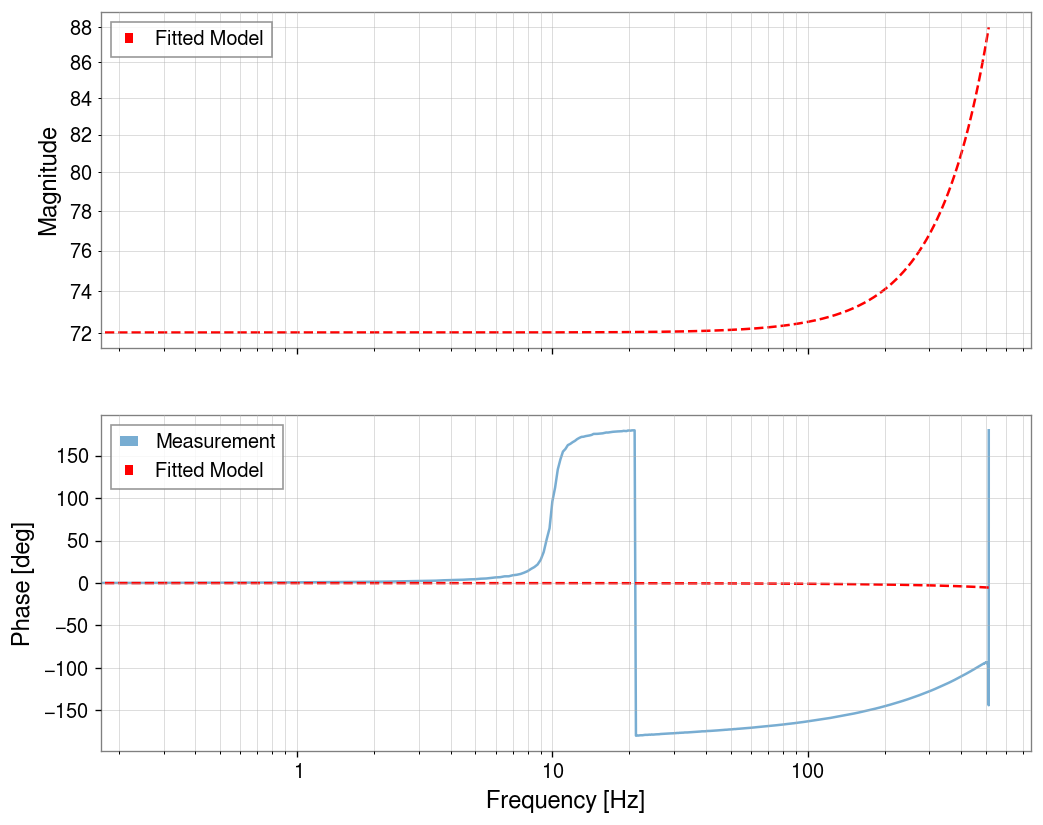

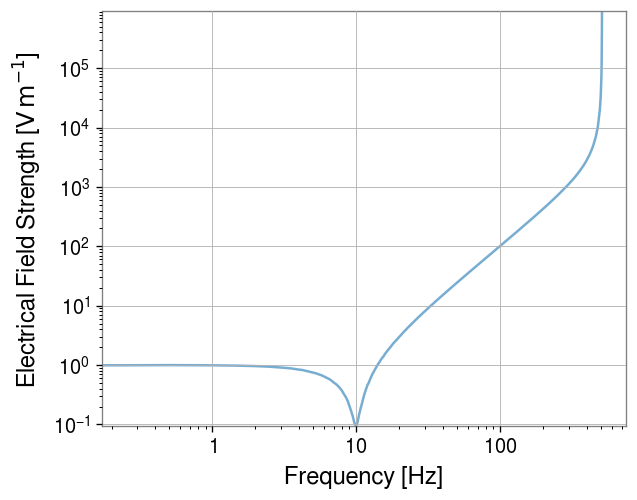

In [4]:
w0_fit = 2 * np.pi * f0_fit
sys_fit = tf([K_fit * w0_fit**2], [1, w0_fit / Q_fit, w0_fit**2])
mag_fit, phase_fit, _ = bode(sys_fit, freqs, plot=False)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
tf_meas.abs().plot(ax=ax1, label="Measurement", alpha=0.6)
ax1.loglog(freqs, mag_fit, "r--", label="Fitted Model")
ax1.set_ylabel("Magnitude")
ax1.legend()
ax1.grid(True, which="both", alpha=0.5)

phase_meas_deg = np.rad2deg(np.angle(tf_meas.value))
ax2.semilogx(freqs, phase_meas_deg, label="Measurement", alpha=0.6)
ax2.semilogx(freqs, np.rad2deg(phase_fit), "r--", label="Fitted Model")
ax2.set_ylabel("Phase [deg]")
ax2.set_xlabel("Frequency [Hz]")
ax2.legend()
ax2.grid(True, which="both", alpha=0.5)
plt.show()
